# LSTM — Stock Prediction (real training)

Synthetic time series → windowing → LSTM training (PyTorch) → forecast plot.

_Last rebuild: **2026-02-16 01:29:20**_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.figsize']=(12,4)


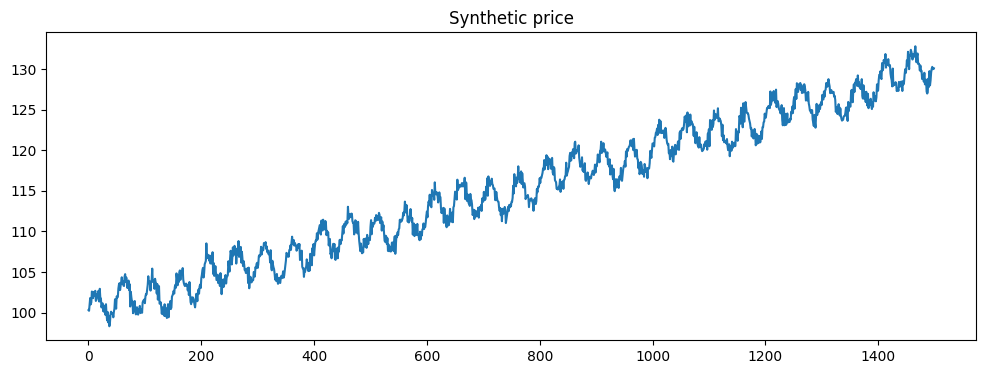

In [2]:
T=1500
t=np.arange(T)
series=100+0.02*t+2*np.sin(2*np.pi*t/50)+0.8*np.sin(2*np.pi*t/200)+np.random.normal(0,0.6,T)
plt.plot(series); plt.title('Synthetic price'); plt.show()

In [3]:
def windows(x, lookback=40):
    X,y=[],[]
    for i in range(lookback, len(x)):
        X.append(x[i-lookback:i]); y.append(x[i])
    return np.array(X), np.array(y)

lookback=40
X,y=windows(series, lookback)
split=int(0.8*len(X))
Xtr,Xte=X[:split],X[split:]
ytr,yte=y[:split],y[split:]

Xtr_t=torch.tensor(Xtr, dtype=torch.float32).unsqueeze(-1)
ytr_t=torch.tensor(ytr, dtype=torch.float32).unsqueeze(-1)
Xte_t=torch.tensor(Xte, dtype=torch.float32).unsqueeze(-1)

train_loader=DataLoader(TensorDataset(Xtr_t,ytr_t), batch_size=64, shuffle=True)
Xtr_t.shape

torch.Size([1168, 40, 1])

In [4]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc=nn.Linear(32,1)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.fc(out[:,-1,:])

model=LSTMForecaster().to(device)
opt=torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn=nn.MSELoss()

for epoch in range(5):
    model.train(); losses=[]
    for xb,yb in train_loader:
        xb,yb=xb.to(device), yb.to(device)
        opt.zero_grad()
        pred=model(xb)
        loss=loss_fn(pred,yb)
        loss.backward(); opt.step()
        losses.append(loss.item())
    print('epoch', epoch+1, 'mse', float(np.mean(losses)))

model.eval()
with torch.no_grad():
    yhat=model(Xte_t.to(device)).cpu().numpy().ravel()

print('test mse:', mean_squared_error(yte, yhat))

epoch 1 mse 12668.41545024671
epoch 2 mse 12648.553762335527
epoch 3 mse 12532.563013980263
epoch 4 mse 12300.699064555922
epoch 5 mse 12119.865337171053
test mse: 15458.542047497845


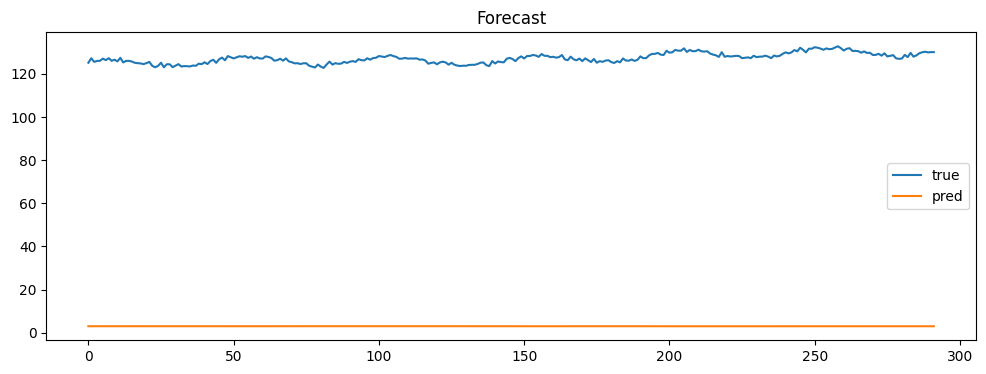

In [5]:
plt.plot(yte[:300], label='true'); plt.plot(yhat[:300], label='pred'); plt.legend(); plt.title('Forecast'); plt.show()

In [6]:
print('DONE 2026-02-16 01:29:20')

DONE 2026-02-16 01:29:20
